In [1]:
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import librosa
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
import numpy as np

data = "./features-relative.csv"

df = pd.read_csv(data)
print(repr(df.columns.tolist()))
df["segment"] = None
for index, row in df.iterrows():
    start_sample = int(row[" Start Sample"])
    end_sample = int(row[" End Sample"])
    signal, fs= librosa.load(row["file"])
    segment = signal[start_sample:end_sample]
    df.at[index, "segment"] = segment  

max_len = max(len(segment) for segment in df["segment"]) 

def pad_segment(segment, max_len):
    if len(segment) > max_len:
        return segment[:max_len]           
    else:
        return np.pad(segment, (0, max_len - len(segment)))  

# Create list to hold all features
features = []

# Add the audio segment as first channel
segments = np.array([pad_segment(seg, max_len) for seg in df["segment"]])
features.append(segments)

# Define numeric columns to use (excluding 'file', 'Label', 'Start Sample', 'End Sample', 'segment')
numeric_cols = ['mean', 'std', 'rms', 'mav', 'iEMG', 'wl', 'zcr', 'spec_entropy', 
                'median_freq', 'skew', 'kurtosis']
base_cols = []
for i in range(1, 11):  # for columns 1-10
    base_cols.extend([f"{col}_{i}" for col in numeric_cols])

# Add other columns from DataFrame
for col in base_cols:
    if col in df.columns:
        # Convert to float and handle any NaN values
        feature_data = df[col].astype(float).fillna(0).values
        # Reshape to (samples, max_len)
        feature_reshaped = np.repeat(feature_data[:, np.newaxis], max_len, axis=1)
        features.append(feature_reshaped)

# Stack all features along the channel dimension
X = np.stack(features, axis=-1)
print("X shape:", X.shape)  # Should be (samples, max_len, n_features)
print("Feature channels:", len(features))

y = df[' Label'] 

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

['Start', ' End', ' Label', ' Start Sample', ' End Sample', ' len_1', 'mean_1', 'std_1', 'rms_1', 'mav_1', 'iEMG_1', 'wl_1', 'zcr_1', 'spec_entropy_1', 'median_freq_1', 'skew_1', 'kurtosis_1', 'len_2', 'mean_2', 'std_2', 'rms_2', 'mav_2', 'iEMG_2', 'wl_2', 'zcr_2', 'spec_entropy_2', 'median_freq_2', 'skew_2', 'kurtosis_2', 'len_3', 'mean_3', 'std_3', 'rms_3', 'mav_3', 'iEMG_3', 'wl_3', 'zcr_3', 'spec_entropy_3', 'median_freq_3', 'skew_3', 'kurtosis_3', 'len_4', 'mean_4', 'std_4', 'rms_4', 'mav_4', 'iEMG_4', 'wl_4', 'zcr_4', 'spec_entropy_4', 'median_freq_4', 'skew_4', 'kurtosis_4', 'len_5', 'mean_5', 'std_5', 'rms_5', 'mav_5', 'iEMG_5', 'wl_5', 'zcr_5', 'spec_entropy_5', 'median_freq_5', 'skew_5', 'kurtosis_5', 'len_6', 'mean_6', 'std_6', 'rms_6', 'mav_6', 'iEMG_6', 'wl_6', 'zcr_6', 'spec_entropy_6', 'median_freq_6', 'skew_6', 'kurtosis_6', 'len_7', 'mean_7', 'std_7', 'rms_7', 'mav_7', 'iEMG_7', 'wl_7', 'zcr_7', 'spec_entropy_7', 'median_freq_7', 'skew_7', 'kurtosis_7', 'len_8', 'mean_

c:\Users\joaqu\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\joaqu\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\joaqu\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


X shape: (3514, 424, 111)
Feature channels: 111


In [2]:
# Print available columns
print("Available columns:", df.columns.tolist())

Available columns: ['Start', ' End', ' Label', ' Start Sample', ' End Sample', ' len_1', 'mean_1', 'std_1', 'rms_1', 'mav_1', 'iEMG_1', 'wl_1', 'zcr_1', 'spec_entropy_1', 'median_freq_1', 'skew_1', 'kurtosis_1', 'len_2', 'mean_2', 'std_2', 'rms_2', 'mav_2', 'iEMG_2', 'wl_2', 'zcr_2', 'spec_entropy_2', 'median_freq_2', 'skew_2', 'kurtosis_2', 'len_3', 'mean_3', 'std_3', 'rms_3', 'mav_3', 'iEMG_3', 'wl_3', 'zcr_3', 'spec_entropy_3', 'median_freq_3', 'skew_3', 'kurtosis_3', 'len_4', 'mean_4', 'std_4', 'rms_4', 'mav_4', 'iEMG_4', 'wl_4', 'zcr_4', 'spec_entropy_4', 'median_freq_4', 'skew_4', 'kurtosis_4', 'len_5', 'mean_5', 'std_5', 'rms_5', 'mav_5', 'iEMG_5', 'wl_5', 'zcr_5', 'spec_entropy_5', 'median_freq_5', 'skew_5', 'kurtosis_5', 'len_6', 'mean_6', 'std_6', 'rms_6', 'mav_6', 'iEMG_6', 'wl_6', 'zcr_6', 'spec_entropy_6', 'median_freq_6', 'skew_6', 'kurtosis_6', 'len_7', 'mean_7', 'std_7', 'rms_7', 'mav_7', 'iEMG_7', 'wl_7', 'zcr_7', 'spec_entropy_7', 'median_freq_7', 'skew_7', 'kurtosis_

In [3]:
LEARNING_RATE = 0.01

from tensorflow.keras.layers import LSTM

from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

# Calculate number of input channels from X shape
n_channels = X.shape[-1]
print(f"Number of input channels: {n_channels}")

model = Sequential([
    Conv1D(64, 7, activation='relu', padding='same', input_shape=(max_len, n_channels)),  # Updated input shape
    MaxPooling1D(2),
    BatchNormalization(),
    Conv1D(128, 5, activation='relu', padding='same'),
    MaxPooling1D(2),
    BatchNormalization(),
    Conv1D(256, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])


Number of input channels: 111


c:\Users\joaqu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:

y_train.shape

(2811,)

In [5]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

monitor = EarlyStopping(monitor='val_loss',
                        mode='min',  # Changed from 'max' to 'min' since we're monitoring loss
                        restore_best_weights=True,
                        patience=5)

In [6]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_split=0.1,
                    callbacks=[monitor],
                    class_weight=class_weights)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - acc: 0.4441 - loss: 1.1918 - val_acc: 0.2021 - val_loss: 1.1977
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - acc: 0.4441 - loss: 1.1918 - val_acc: 0.2021 - val_loss: 1.1977
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - acc: 0.4733 - loss: 0.9508

KeyboardInterrupt: 

In [ ]:
# Check shapes and data types
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)
print("Number of unique classes in y_train:", len(np.unique(y_train)))
print("\nModel input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

X_train shape: (2811, 424, 111)
y_train shape: (2811,)
X_train dtype: float64
y_train dtype: int32
Number of unique classes in y_train: 3

Model input shape: (None, 424, 111)
Model output shape: (None, 3)



++++++++++++ Test data ++++++++++++
loss=0.8952 acc=0.5932


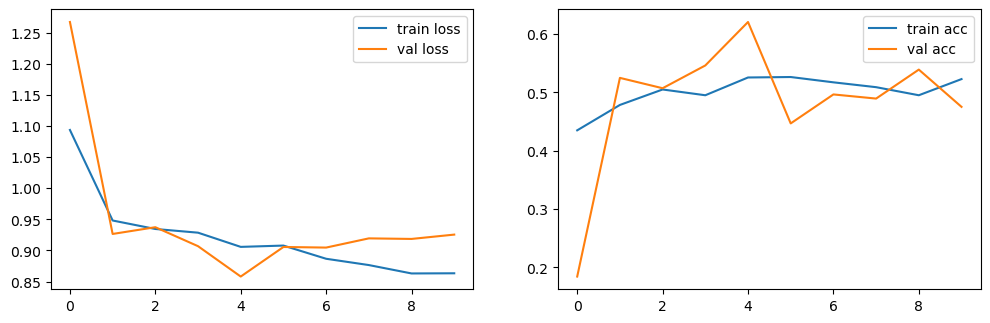

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['acc'], label='train acc')
plt.plot(history.history['val_acc'], label='val acc')
plt.legend()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n++++++++++++ Test data ++++++++++++\nloss={loss:.4f} acc={acc:.4f}")

In [ ]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_39 (Conv1D)              │ (None, 424, 64)        │        49,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_39 (MaxPooling1D) │ (None, 212, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 212, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_40 (Conv1D)              │ (None, 212, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_40 (MaxPooling1D) │ (None, 106, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 106, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_41 (Conv1D)              │ (None, 106, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_41 (MaxPooling1D) │ (None, 53, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 53, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 13568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │     1,736,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,781,515 (22.05 MB)

 Trainable params: 1,927,043 (7.35 MB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 3,854,088 (14.70 MB)